In [1]:
! pip install geopandas shapely


   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 266.1 kB/s eta 0:00:05
   ------------ ---------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import geopandas as gpd

gdf = gpd.read_file("2011_Dist.shp")

print(gdf.columns)


Index(['DISTRICT', 'ST_NM', 'ST_CEN_CD', 'DT_CEN_CD', 'censuscode',
       'geometry'],
      dtype='object')


In [3]:
gdf["DISTRICT"] = gdf["DISTRICT"].str.upper()
print(gdf["DISTRICT"])

0                    ADILABAD
1                        AGRA
2                   AHMADABAD
3                  AHMADNAGAR
4                      AIZAWL
                ...          
636                      TAPI
637                   NICOBAR
638             SOUTH ANDAMAN
639    NORTH & MIDDLE ANDAMAN
640               LAKSHADWEEP
Name: DISTRICT, Length: 641, dtype: object


In [4]:
from itertools import combinations

districts = gdf["DISTRICT"].tolist()
N = len(districts)

import numpy as np
A = np.zeros((N, N))

for i, j in combinations(range(N), 2):
    if gdf.geometry[i].touches(gdf.geometry[j]):
        A[i, j] = 1
        A[j, i] = 1


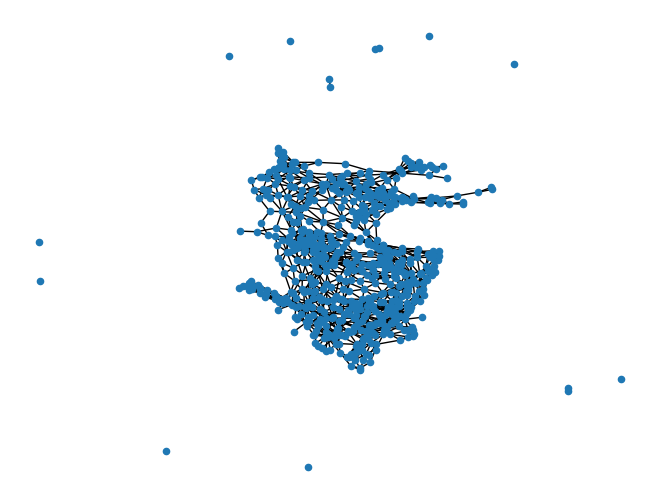

In [5]:
import networkx as nx

G = nx.from_numpy_array(A)
nx.draw(G, node_size=20)


In [6]:
district_index = districts.index("CHENNAI")
neighbors = np.where(A[district_index] == 1)[0]

print("Neighbors of Chennai:")
for n in neighbors:
    print(districts[n])


Neighbors of Chennai:
KANCHEEPURAM
THIRUVALLUR
